# Practico 4, Trabajo de estadisticas con el NEA (MISIONES, CORRIENTES, FORMOSA, CHACO)

In [43]:
import pandas
import numpy
from datetime import timedelta
import missingno
import matplotlib.pyplot as pyplot
import seaborn
from scipy.stats import entropy

In [44]:
dataset = pandas.read_csv('../datasets/smn_historico.csv',na_values=['S/D'])

#### Primero refinamos la bd

In [53]:
# Convertir categóricas a tipo 'category' para ejecutar describe correctamente
dataset['estacion'] = dataset['estacion'].astype('category')
dataset['mes_txt'] = dataset['mes_txt'].astype('category')
dataset['provincia'] = dataset['provincia'].astype('category')
dataset['NroOACI'] = dataset['NroOACI'].astype('category')
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1176 entries, 0 to 1175
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   estacion      1176 non-null   category
 1   provincia     1152 non-null   category
 2   altura        1152 non-null   float64 
 3   numero        1152 non-null   float64 
 4   NroOACI       1140 non-null   category
 5   LAT_decimal   1152 non-null   float64 
 6   LON_decimal   1152 non-null   float64 
 7   mes_txt       1176 non-null   category
 8   prec_sup_1mm  1061 non-null   float64 
 9   humedad       1110 non-null   float64 
 10  nubosidad     1166 non-null   float64 
 11  prec_mm       1061 non-null   float64 
 12  temp          1167 non-null   float64 
 13  temp_max      1158 non-null   float64 
 14  temp_min      1124 non-null   float64 
 15  viento        708 non-null    float64 
dtypes: category(4), float64(12)
memory usage: 121.7 KB


In [46]:
dataset.head()

,estacion,provincia,altura,numero,NroOACI,LAT_decimal,LON_decimal,mes_txt,prec_sup_1mm,humedad,nubosidad,prec_mm,temp,temp_max,temp_min,viento
0,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Ene,6.7,67.0,3.1,117.5,24.5,28.4,20.8,16.8
1,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Feb,6.0,69.8,3.2,112.3,23.7,27.3,20.2,15.8
2,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Mar,5.9,71.3,3.1,111.8,22.0,25.5,18.8,14.9
3,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Abr,6.6,73.6,3.5,108.3,18.5,22.0,15.3,13.9
4,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,May,5.0,76.4,4.0,83.3,15.2,18.4,12.3,12.9


In [47]:
dataset.shape

(1176, 16)

In [48]:
#Extraemos solo las del NEA
provincias_nea = ['CHACO', 'CORRIENTES', 'FORMOSA', 'MISIONES']

#por las dudas filtramos
dataset['provincia'].str.strip().str.upper()
dataset_nea = dataset[dataset['provincia'].isin(provincias_nea)]

dataset_nea.head()

,estacion,provincia,altura,numero,NroOACI,LAT_decimal,LON_decimal,mes_txt,prec_sup_1mm,humedad,nubosidad,prec_mm,temp,temp_max,temp_min,viento
120,BERNARDO DE IRIGOYEN AERO,MISIONES,815.0,87163.0,SATI,-26.266667,-53.666667,Ene,11.9,77.6,5.3,207.1,22.9,28.1,19.0,NaN
121,BERNARDO DE IRIGOYEN AERO,MISIONES,815.0,87163.0,SATI,-26.266667,-53.666667,Feb,11.0,78.6,5.2,189.1,22.6,27.6,18.8,NaN
122,BERNARDO DE IRIGOYEN AERO,MISIONES,815.0,87163.0,SATI,-26.266667,-53.666667,Mar,10.1,77.9,4.8,181.0,21.7,26.9,17.9,NaN
123,BERNARDO DE IRIGOYEN AERO,MISIONES,815.0,87163.0,SATI,-26.266667,-53.666667,Abr,7.7,77.7,4.5,173.9,19.6,24.4,15.9,NaN
124,BERNARDO DE IRIGOYEN AERO,MISIONES,815.0,87163.0,SATI,-26.266667,-53.666667,May,8.6,79.0,4.7,196.1,16.2,20.6,12.9,NaN


In [49]:
dataset_nea.shape

(132, 16)

#### 1.Cuantas estaciones hay en la region?

In [50]:
# esto es una manera, pero luego uso las estaciones por separado
#cantidad_estaciones = estaciones_nea['estacion'].nunique()
#print(f"Total de estaciones: {cantidad_estaciones}")

estaciones_nea_unicas = dataset_nea['estacion'].unique()
print(f"Total de estaciones: {len(estaciones_nea_unicas)}")


Total de estaciones: 11


#### 2. ¿Cuál es la altura media de las estaciones en la región?

In [51]:
estaciones_nea_unicas = dataset_nea.drop_duplicates(subset=['estacion'])
altura_media = estaciones_nea_unicas['altura'].mean()
print(f"Altura media: {altura_media}")
estaciones_nea_unicas.head(15)


Altura media: 184.9090909090909


,estacion,provincia,altura,numero,NroOACI,LAT_decimal,LON_decimal,mes_txt,prec_sup_1mm,humedad,nubosidad,prec_mm,temp,temp_max,temp_min,viento
120,BERNARDO DE IRIGOYEN AERO,MISIONES,815.0,87163.0,SATI,-26.266667,-53.666667,Ene,11.9,77.6,5.3,207.1,22.9,28.1,19.0,NaN
252,CORRIENTES AERO,CORRIENTES,62.0,87166.0,SARC,-27.433333,-58.750000,Ene,7.6,71.6,3.5,179.5,26.9,33.0,21.6,11.6
372,FORMOSA AERO,FORMOSA,60.0,87162.0,SARF,-26.200000,-58.216667,Ene,7.6,71.5,4.0,163.5,27.7,34.1,22.5,12.4
420,IGUAZU AERO,MISIONES,270.0,87097.0,SARI,-25.716667,-54.466667,Ene,9.3,79.0,3.9,180.1,25.8,32.0,20.7,9.1
540,LAS LOMITAS,FORMOSA,130.0,87078.0,SATK,-24.700000,-60.583333,Ene,6.7,67.9,3.9,130.3,28.3,35.5,22.1,5.4
624,MONTE CASEROS AERO,CORRIENTES,54.0,87393.0,SARM,-30.250000,-57.633333,Ene,7.4,68.4,3.3,157.4,26.2,32.4,20.6,11.2
660,OBERA,MISIONES,303.0,87187.0,SATO,-27.483333,-55.116667,Ene,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
708,PASO DE LOS LIBRES AERO,CORRIENTES,70.0,87289.0,SARL,-29.683333,-57.133333,Ene,6.9,69.7,3.7,143.9,26.0,32.2,20.6,16.5
768,POSADAS AERO,MISIONES,125.0,87178.0,SARP,-27.383333,-55.966667,Ene,8.1,68.1,3.4,168.7,27.2,33.0,22.1,9.8
780,PRESIDENCIA ROQUE SAENZ PEÑA AERO,CHACO,93.0,87148.0,SARS,-26.733333,-60.483333,Ene,7.6,71.1,3.6,164.3,27.1,33.8,NaN,NaN


#### 3. ¿Cuál es la temperatura media (temp) de la región?

In [54]:
dataset_nea['temp'].mean()

np.float64(21.13671875)

#### 4. ¿Cuál es el desvío estándar de la temperatura (temp) en la región?

In [55]:
dataset_nea['temp'].std()

np.float64(4.0613963522075025)

#### 5. ¿En qué mes se registra la mayor precipitación media (prec_mm) en la región? 

In [56]:
#primero me quiero asgurar que esten todos los meses
dataset_nea['mes_txt'].nunique()

12

In [60]:
precipitacion_por_mes = dataset_nea.groupby('mes_txt')['prec_mm'].mean()
print(precipitacion_por_mes)

mes_txt
Abr    165.027273
Ago     54.580000
Dic    172.780000
Ene    167.470000
Feb    144.270000
Jul     59.220000
Jun     91.809091
Mar    153.880000
May    118.390909
Nov    162.427273
Oct    171.980000
Sep     97.609091
Name: prec_mm, dtype: float64


/tmp/ipykernel_24472/1061378314.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  precipitacion_por_mes = dataset_nea.groupby('mes_txt')['prec_mm'].mean()


#### 6. Dentro de la región elegida, ¿Qué provincia tiene la mayor temperatura media?

In [62]:
temp_por_provincia = dataset_nea.groupby('provincia', observed=True)['temp'].mean()
print(temp_por_provincia)

provincia
CHACO         21.295833
CORRIENTES    20.352778
FORMOSA       22.720833
MISIONES      20.827273
Name: temp, dtype: float64


#### 7.¿En cuál de estas variables aparecen valores atípicos (outliers) en la región?

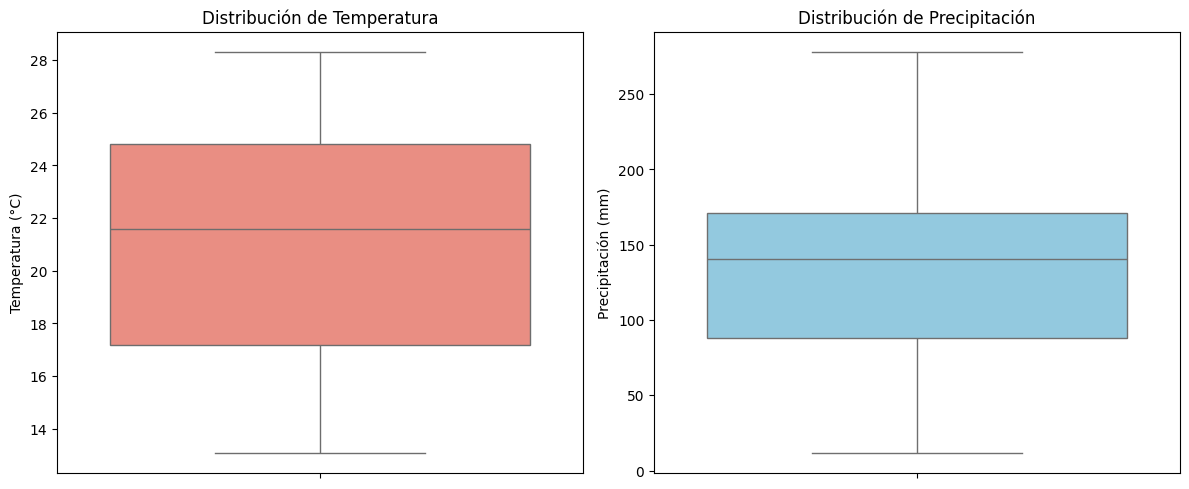

In [63]:
# Configurar el lienzo para 2 gráficos
fig, axes = pyplot.subplots(1, 2, figsize=(12, 5))

# Boxplot para Temperatura
seaborn.boxplot(y=dataset_nea['temp'], ax=axes[0], color='salmon')
axes[0].set_title('Distribución de Temperatura')
axes[0].set_ylabel('Temperatura (°C)')

# Boxplot para Precipitación
seaborn.boxplot(y=dataset_nea['prec_mm'], ax=axes[1], color='skyblue')
axes[1].set_title('Distribución de Precipitación')
axes[1].set_ylabel('Precipitación (mm)')

pyplot.tight_layout()
pyplot.show()

In [64]:
dataset_nea['temp'].max()

np.float64(28.3)

#### 8.Luego de calcular el coeficiente de correlación de Spearman entre la altura de las estaciones y la temperatura media para la región elegida, concluimos que: 

In [65]:
# 2. Calcular la correlación de Spearman entre altura y temperatura
spearman_corr = dataset_nea['altura'].corr(dataset_nea['temp'], method='spearman')
print(f"Coeficiente de Spearman: {spearman_corr:.4f}")

Coeficiente de Spearman: -0.0402


In [70]:
from scipy.stats import f_oneway
def eta_squared(continuous, categorical):
    mask       = continuous.notna() & categorical.notna()
    y, grp     = continuous[mask], categorical[mask]
    groups     = [g.values for _, g in y.groupby(grp, observed=True)]
    F, p       = f_oneway(*groups)
    grand_mean = y.mean()
    ss_total   = ((y - grand_mean) ** 2).sum()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    return ss_between / ss_total, p, F

#### 9.Basándote en el valor de eta cuadrado para las variables provincia y precipitación de la región elegida, ¿Qué podrías afirmar?

In [ ]:
# 2. Ejecutar la función con tus datos del NEA
eta, p_val, f_stat = eta_squared(dataset_nea['prec_mm'], dataset_nea['provincia'])

# 3. Ver los resultados descomprimidos
print(f"Eta cuadrado: {eta:.4f}")
print(f"p-valor: {p_val:.8f}")
print(f"Estadístico F: {f_stat:.4f}")

Eta cuadrado: 0.2664
p-valor: 0.00000003
Estadístico F: 14.6447


#### 10. Chaco general

In [74]:
dataset_chaco = dataset_nea[dataset_nea['provincia']=='CHACO']
dataset_chaco.head()

,estacion,provincia,altura,numero,NroOACI,LAT_decimal,LON_decimal,mes_txt,prec_sup_1mm,humedad,nubosidad,prec_mm,temp,temp_max,temp_min,viento
780,PRESIDENCIA ROQUE SAENZ PEÑA AERO,CHACO,93.0,87148.0,SARS,-26.733333,-60.483333,Ene,7.6,71.1,3.6,164.3,27.1,33.8,NaN,NaN
781,PRESIDENCIA ROQUE SAENZ PEÑA AERO,CHACO,93.0,87148.0,SARS,-26.733333,-60.483333,Feb,6.5,73.3,3.6,115.8,26.3,33.0,NaN,NaN
782,PRESIDENCIA ROQUE SAENZ PEÑA AERO,CHACO,93.0,87148.0,SARS,-26.733333,-60.483333,Mar,7.3,77.1,3.5,137.0,24.4,31.3,NaN,NaN
783,PRESIDENCIA ROQUE SAENZ PEÑA AERO,CHACO,93.0,87148.0,SARS,-26.733333,-60.483333,Abr,6.6,81.1,3.9,117.6,21.1,27.7,NaN,NaN
784,PRESIDENCIA ROQUE SAENZ PEÑA AERO,CHACO,93.0,87148.0,SARS,-26.733333,-60.483333,May,4.6,81.3,4.0,48.8,17.0,23.8,NaN,NaN


In [77]:
variables = ['temp', 'prec_mm', 'humedad', 'nubosidad', 'viento']
estadisticas_mensuales = dataset_chaco.groupby('mes_txt', observed=False)[variables].agg(['mean', 'min', 'max'])
print(estadisticas_mensuales)

          temp             prec_mm               humedad              \
          mean   min   max    mean    min    max    mean   min   max   
mes_txt                                                                
Abr      21.25  21.1  21.4  141.35  117.6  165.1   80.55  80.0  81.1   
Ago      16.95  16.9  17.0   30.05   24.8   35.3   67.65  64.8  70.5   
Dic      26.10  26.0  26.2  145.15  133.6  156.7   70.40  69.4  71.4   
Ene      27.00  26.9  27.1  172.10  164.3  179.9   71.30  71.1  71.5   
Feb      26.20  26.1  26.3  136.30  115.8  156.8   73.70  73.3  74.1   
Jul      14.55  14.3  14.8   18.60   12.8   24.4   75.20  73.8  76.6   
Jun      15.60  15.4  15.8   41.65   23.4   59.9   81.30  80.7  81.9   
Mar      24.45  24.4  24.5  149.00  137.0  161.0   76.90  76.7  77.1   
May      17.35  17.0  17.7   67.75   48.8   86.7   81.75  81.3  82.2   
Nov      24.05  23.8  24.3  150.40  125.3  175.5   69.85  68.5  71.2   
Oct      22.60  22.2  23.0  118.25   98.3  138.2   69.60  67.3  